In [54]:
# IMPORTS
import json;
import pandas as pd;
import matplotlib.pyplot as plt;
from collections import Counter;
import torch;

In [55]:
with open("../../data/tacred/train.json") as file:
  data = json.load(file);

In [56]:
print("Number of TACRED examples in training set:", len(data));

Number of TACRED examples in training set: 68124


In [57]:
df = pd.DataFrame(data);
print(df.head());

                     id                             docid        relation  \
0  61b3a5c8c9a882dcfcd2  AFP_ENG_20070218.0019.LDC2009T13  org:founded_by   
1  61b3a65fb9b7111c4ca4  NYT_ENG_20071026.0056.LDC2009T13     no_relation   
2  61b3a65fb9aeb61c81e7          eng-NG-31-126955-9171242     no_relation   
3  61b3a65fb9c9956eccbc             APW_ENG_20100119.0780     no_relation   
4  61b3a65fb9197aba87ff  APW_ENG_20070501.0905.LDC2009T13     no_relation   

                                               token  subj_start  subj_end  \
0  [Tom, Thabane, resigned, in, October, last, ye...          10        12   
1  [In, 1983, ,, a, year, after, the, rally, ,, F...           9         9   
2  [This, was, among, a, batch, of, paperback, Ox...          26        26   
3  [The, latest, investigation, was, authorized, ...          55        55   
4  [The, event, is, a, response, to, a, White, Ho...          23        26   

   obj_start  obj_end     subj_type      obj_type  \
0          0   

In [58]:
mapping = {
  'subject': {
    'type': 'subj_type',
    'start': 'subj_start',
    'end': 'subj_end'
  },
  'object': {
    'type': 'obj_type',
    'start': 'obj_start',
    'end': 'obj_end'
  }
};

In [59]:
print(mapping);

{'subject': {'type': 'subj_type', 'start': 'subj_start', 'end': 'subj_end'}, 'object': {'type': 'obj_type', 'start': 'obj_start', 'end': 'obj_end'}}


In [60]:
def getEntityTypeAndPosTag(raw_data, sample_index, entity_sub_or_obj='subject'):
  # fetch the specified example by indexing into the dataset
  target_sample = raw_data[sample_index];
  # obtain the position of the entity (subject or object) via the above-defined mapping
  entity_type = target_sample[mapping[entity_sub_or_obj]['type']];
  start_idx = target_sample[mapping[entity_sub_or_obj]['start']];
  end_idx = target_sample[mapping[entity_sub_or_obj]['end']];
  # get the PoS tags
  pos_tags = target_sample['stanford_pos'][start_idx: end_idx + 1];
  tokens = target_sample['token'][start_idx: end_idx + 1];
  return {'entity_type': entity_type, 'tokens': tokens, 'pos_tags': pos_tags};


In [61]:
print(getEntityTypeAndPosTag(data, 42));

{'entity_type': 'PERSON', 'tokens': ['Steve', 'McPherson'], 'pos_tags': ['NNP', 'NNP']}


In [62]:
print(getEntityTypeAndPosTag(data, 1964));

{'entity_type': 'ORGANIZATION', 'tokens': ['Scorpions'], 'pos_tags': ['NNP']}


In [63]:
for x in range(42, 96):
  print(getEntityTypeAndPosTag(data, x));

{'entity_type': 'PERSON', 'tokens': ['Steve', 'McPherson'], 'pos_tags': ['NNP', 'NNP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['ANP'], 'pos_tags': ['NNP']}
{'entity_type': 'PERSON', 'tokens': ['Boyle'], 'pos_tags': ['NNP']}
{'entity_type': 'PERSON', 'tokens': ['he'], 'pos_tags': ['PRP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['Zagat'], 'pos_tags': ['NNP']}
{'entity_type': 'PERSON', 'tokens': ['Kim'], 'pos_tags': ['NNP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['Covidien'], 'pos_tags': ['NNP']}
{'entity_type': 'PERSON', 'tokens': ['he'], 'pos_tags': ['PRP']}
{'entity_type': 'PERSON', 'tokens': ['William', 'Anderson'], 'pos_tags': ['NNP', 'NNP']}
{'entity_type': 'PERSON', 'tokens': ['Dan', 'Abrams'], 'pos_tags': ['NNP', 'NNP']}
{'entity_type': 'PERSON', 'tokens': ['Josephine', 'Robinson', 'McNair'], 'pos_tags': ['NNP', 'NNP', 'NNP']}
{'entity_type': 'PERSON', 'tokens': ['Cowell'], 'pos_tags': ['NNP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['Professional', 'Rodeo', 'Cowboys

In [64]:
pos_count = Counter();

for example in data:
  subject_pos_tags = example['stanford_pos'][example['subj_start'] : example['subj_end'] + 1];
  object_pos_tags = example['stanford_pos'][example['obj_start'] : example['obj_end'] + 1];
  pos_count.update(subject_pos_tags);
  pos_count.update(object_pos_tags);

tags = list(pos_count.keys());
counts = list(pos_count.values());

print(tags);
print(counts);

['DT', 'NNP', 'NN', 'CD', 'IN', 'PRP', 'JJ', 'NNPS', 'VBP', 'NNS', 'PRP$', 'RB', 'CC', 'FW', '``', ':', ',', 'VBN', 'RBR', 'MD', 'VBZ', 'POS', 'VBD', 'VBG', 'VB', 'LS', "''", 'JJR', 'JJS', '-RRB-', 'TO', '-LRB-', 'RP', '#', 'WDT', '.', 'UH', '$', 'SYM', 'WP']
[2137, 157671, 13906, 9142, 2906, 10254, 6666, 3435, 37, 2449, 8220, 995, 869, 125, 74, 103, 274, 91, 93, 24, 36, 241, 34, 118, 136, 41, 46, 44, 20, 15, 63, 13, 3, 3, 2, 3, 11, 2, 11, 9]


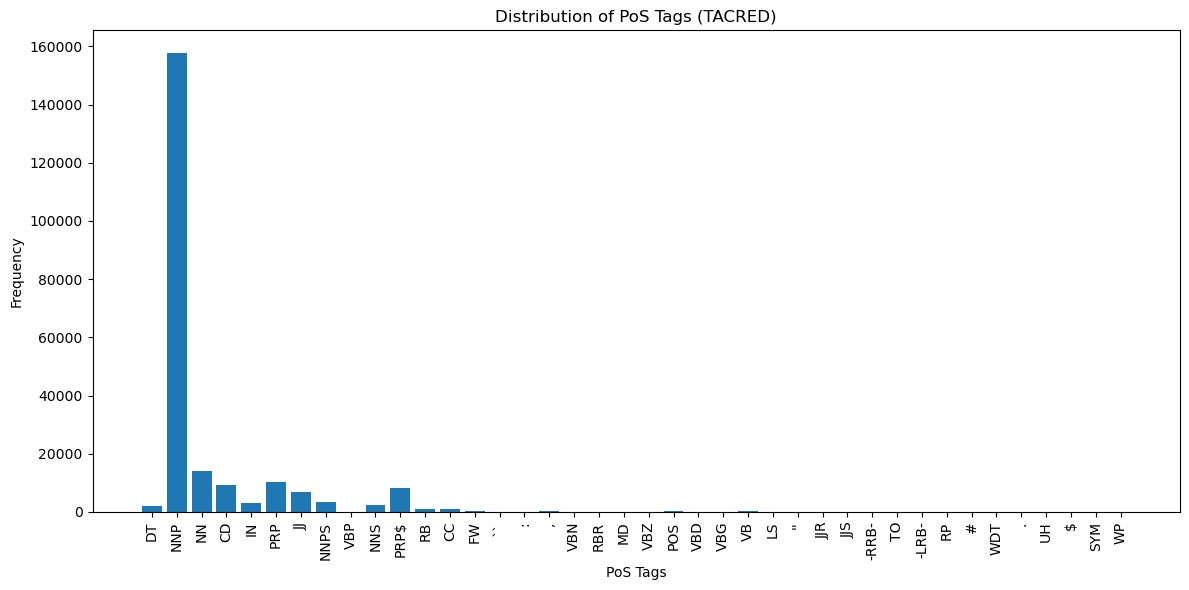

In [65]:
plt.figure(figsize=(12, 6));
plt.bar(tags, counts);
plt.xlabel("PoS Tags");
plt.ylabel("Frequency");
plt.title("Distribution of PoS Tags (TACRED)");
plt.xticks(rotation=90);
plt.tight_layout();
plt.show();

In [66]:
with open("../../data/retacred/train.json") as file:
  retacred_data = json.load(file);

In [67]:
for x in range(42, 96):
  print(getEntityTypeAndPosTag(retacred_data, x));

{'entity_type': 'PERSON', 'tokens': ['Dan', 'Abrams'], 'pos_tags': ['NNP', 'NNP']}
{'entity_type': 'PERSON', 'tokens': ['Josephine', 'Robinson', 'McNair'], 'pos_tags': ['NNP', 'NNP', 'NNP']}
{'entity_type': 'PERSON', 'tokens': ['Cowell'], 'pos_tags': ['NNP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['Professional', 'Rodeo', 'Cowboys', 'Association'], 'pos_tags': ['JJ', 'NNP', 'NNPS', 'NNP']}
{'entity_type': 'PERSON', 'tokens': ['he'], 'pos_tags': ['PRP']}
{'entity_type': 'PERSON', 'tokens': ['him'], 'pos_tags': ['PRP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['SAC'], 'pos_tags': ['NN']}
{'entity_type': 'ORGANIZATION', 'tokens': ['PRC'], 'pos_tags': ['NNP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['FAW'], 'pos_tags': ['NNP']}
{'entity_type': 'PERSON', 'tokens': ['his'], 'pos_tags': ['PRP$']}
{'entity_type': 'PERSON', 'tokens': ['he'], 'pos_tags': ['PRP']}
{'entity_type': 'PERSON', 'tokens': ['she'], 'pos_tags': ['PRP']}
{'entity_type': 'ORGANIZATION', 'tokens': ['Paralyzed', 'Ve

In [68]:
re_pos_count = Counter();

for example in retacred_data:
  re_subject_pos_tags = example['stanford_pos'][example['subj_start'] : example['subj_end'] + 1];
  re_object_pos_tags = example['stanford_pos'][example['obj_start'] : example['obj_end'] + 1];
  re_pos_count.update(re_subject_pos_tags);
  re_pos_count.update(re_object_pos_tags);

retacred_tags = list(re_pos_count.keys());
retacred_counts = list(re_pos_count.values());

print(retacred_tags);
print(retacred_counts);

['DT', 'NNP', 'NN', 'CD', 'IN', 'PRP', 'JJ', 'NNPS', 'VBP', 'NNS', 'PRP$', 'RB', 'CC', 'FW', '``', ':', 'VBN', ',', 'RBR', 'MD', 'POS', 'VBG', 'LS', "''", 'JJR', 'JJS', '-RRB-', 'VB', '-LRB-', 'TO', 'RP', 'VBZ', 'VBD', 'WDT', '#', 'UH', '.', 'WP', 'SYM']
[1912, 137357, 11291, 7939, 2474, 9356, 5356, 2548, 19, 1935, 7482, 873, 744, 48, 29, 81, 38, 251, 90, 13, 203, 73, 27, 27, 38, 8, 13, 72, 10, 13, 3, 17, 13, 1, 2, 2, 1, 3, 2]


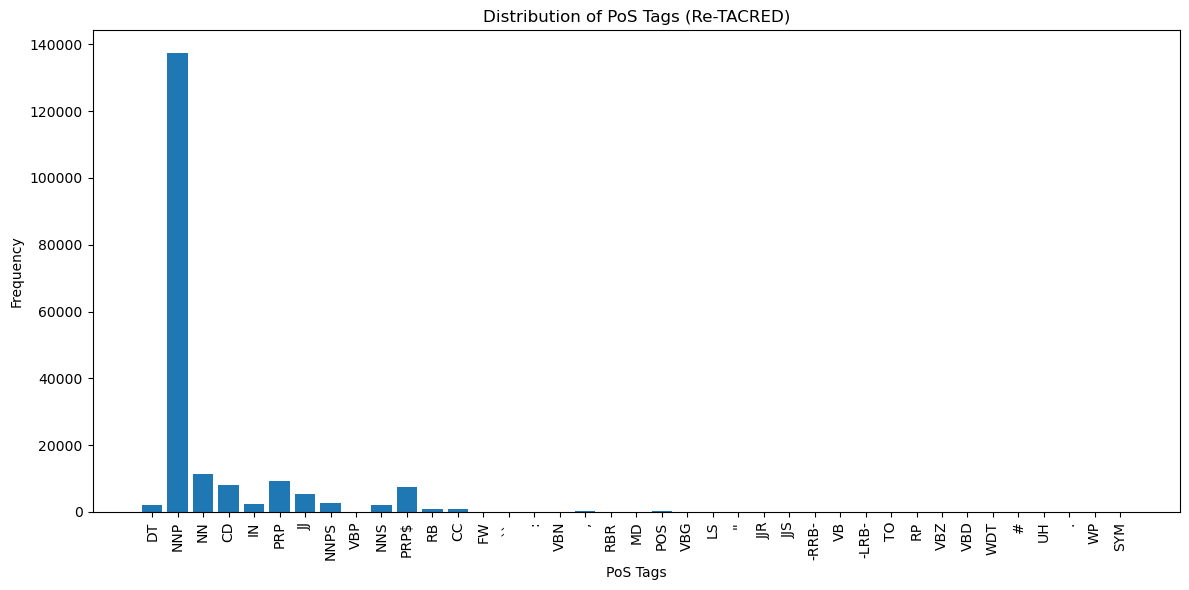

In [69]:
plt.figure(figsize=(12, 6));
plt.bar(retacred_tags, retacred_counts);
plt.xlabel("PoS Tags");
plt.ylabel("Frequency");
plt.title("Distribution of PoS Tags (Re-TACRED)");
plt.xticks(rotation=90);
plt.tight_layout();
plt.show();

In [70]:
print("Number of PoS tags in TACRED: " + str(len(tags)));
print("Number of PoS tags in Re-TACRED: " + str(len(retacred_tags)));

Number of PoS tags in TACRED: 40
Number of PoS tags in Re-TACRED: 39


In [71]:
set(tags).difference(set(retacred_tags))

{'$'}

In [73]:
tags.index('$')

37

In [74]:
tags[37]

'$'

In [75]:
counts[37]

2

In [79]:
modified_tags = tags.copy();
del modified_tags[37];
len(modified_tags)

39

In [80]:
modified_counts = counts.copy();
del modified_counts[37];
len(modified_counts)

39

In [82]:
len(modified_counts) == len(retacred_counts) and len(modified_tags) == len(retacred_tags)

True

In [85]:
set(modified_tags) == set(retacred_tags)

True

In [86]:
print(modified_tags);
print(retacred_tags);

['DT', 'NNP', 'NN', 'CD', 'IN', 'PRP', 'JJ', 'NNPS', 'VBP', 'NNS', 'PRP$', 'RB', 'CC', 'FW', '``', ':', ',', 'VBN', 'RBR', 'MD', 'VBZ', 'POS', 'VBD', 'VBG', 'VB', 'LS', "''", 'JJR', 'JJS', '-RRB-', 'TO', '-LRB-', 'RP', '#', 'WDT', '.', 'UH', 'SYM', 'WP']
['DT', 'NNP', 'NN', 'CD', 'IN', 'PRP', 'JJ', 'NNPS', 'VBP', 'NNS', 'PRP$', 'RB', 'CC', 'FW', '``', ':', 'VBN', ',', 'RBR', 'MD', 'POS', 'VBG', 'LS', "''", 'JJR', 'JJS', '-RRB-', 'VB', '-LRB-', 'TO', 'RP', 'VBZ', 'VBD', 'WDT', '#', 'UH', '.', 'WP', 'SYM']


In [87]:
modified_tags.index('FW')

13

In [88]:
truncated_tags = modified_tags.copy();
del truncated_tags[14:];
truncated_retacred_tags = retacred_tags.copy();
del truncated_retacred_tags[14:];
truncated_counts = modified_counts.copy();
del truncated_counts[14:];
truncated_retacred_counts = retacred_counts.copy();
del truncated_retacred_counts[14:];

In [89]:
truncated_tags == truncated_retacred_tags

True

In [96]:
torch.set_printoptions(profile='default');
torch.set_printoptions(sci_mode=False);
t_tacred_counts = torch.FloatTensor(truncated_counts);
t_retacred_counts = torch.FloatTensor(truncated_retacred_counts);
t_diff_between_counts = t_tacred_counts - t_retacred_counts;
print(t_diff_between_counts);

tensor([      225.,     20314.,      2615.,      1203.,       432.,       898.,
             1310.,       887.,        18.,       514.,       738.,       122.,
              125.,        77.])
